**Part 1: Matplotlib — The Foundation**


In [22]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

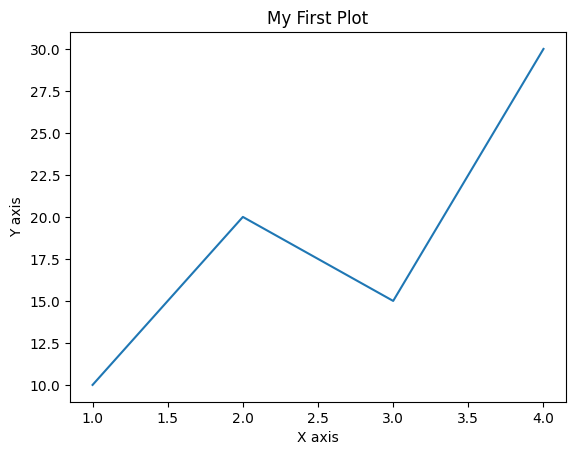

In [23]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# Clean it first (Future-proofed)
df['Age'] = df['Age'].fillna(df['Age'].median())
df = df.dropna(subset=['Embarked'])
df = df.drop('Cabin', axis=1)
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# Basic line plot
plt.plot([1, 2, 3, 4], [10, 20, 15, 30])
plt.title("My First Plot")
plt.xlabel("X axis")
plt.ylabel("Y axis")
plt.show()

That's the anatomy of every Matplotlib plot: data → labels → show

**Part 2: Seaborn — Smarter Visualizations with Less Code**

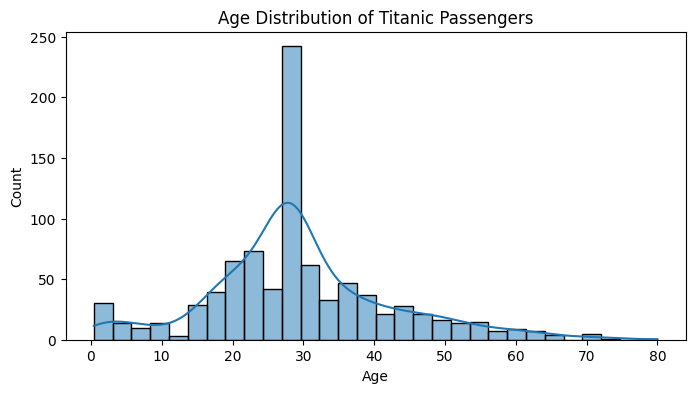

In [24]:
import seaborn as sns
# Distribution of ages
plt.figure(figsize=(8,4))
sns.histplot(df['Age'], bins=30, kde=True)
plt.title("Age Distribution of Titanic Passengers")
plt.show()

✅ Plot 1: Most passengers are between 10–60 years old


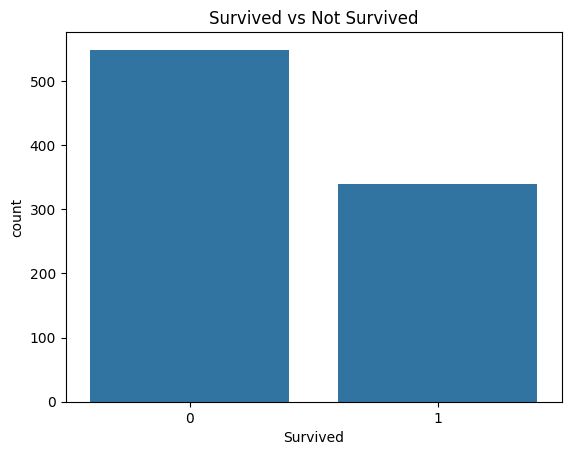

In [25]:
# Survival count
sns.countplot(x='Survived', data=df)
plt.title("Survived vs Not Survived")
plt.show()

✅ Plot 2: More people died than survived


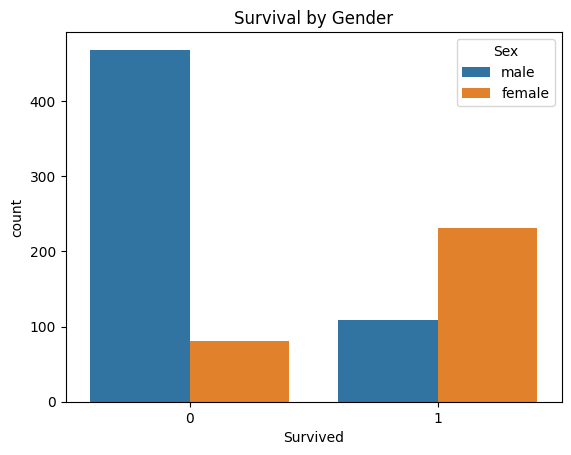

In [26]:
# Survival by gender — ONE line, huge insight
sns.countplot(x='Survived', hue='Sex', data=df)
plt.title("Survival by Gender")
plt.show()

✅ Plot 3: Females had a significantly higher survival rate than males

**Part 3: The EDA Mindset (this is the real skill)
EDA = Exploratory Data Analysis. You're a detective — you don't know what matters yet. Your job is to ask questions and let the data answer.
Classic questions to ask any dataset:**
*   What's the distribution of each variable?
*   Are there correlations between features?
*   Which features seem related to the target (Survived)?





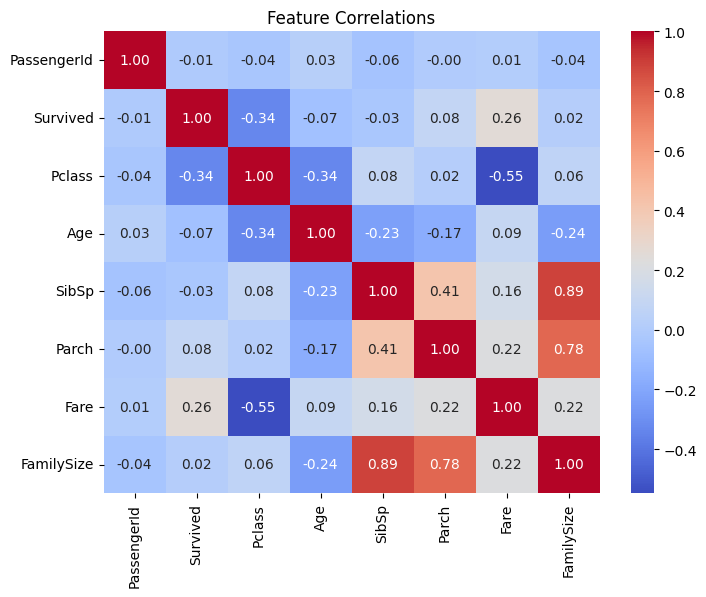

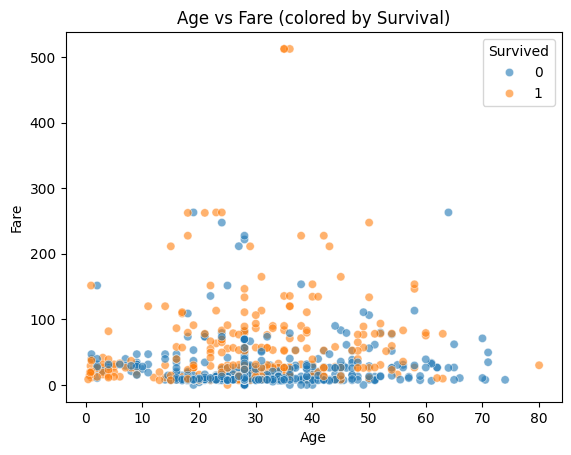

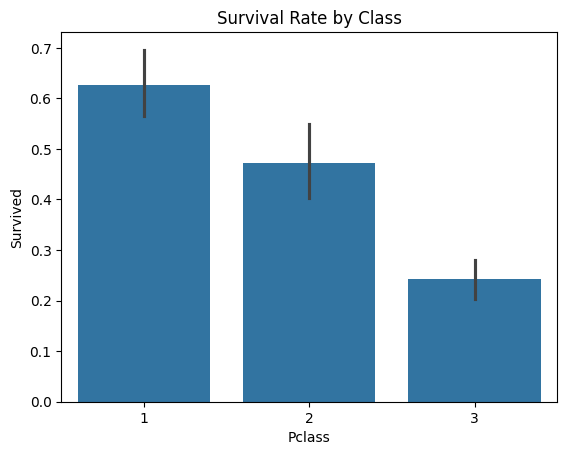

In [27]:
# Correlation heatmap — shows relationships between ALL numeric columns at once (Heatmap)
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Feature Correlations")
plt.show()

# Age vs Fare, colored by survival (Scatterplot)
sns.scatterplot(x='Age', y='Fare', hue='Survived', data=df, alpha=0.6)
plt.title("Age vs Fare (colored by Survival)")
plt.show()

# Survival rate by passenger class (Barplot)
sns.barplot(x='Pclass', y='Survived', data=df)
plt.title("Survival Rate by Class")
plt.show()

## Titanic EDA — Key Insights

1. **Gender was the strongest survival factor** — females survived
   at a much higher rate than males ("women and children first" policy)

2. **Passenger class predicted survival** — Class 1 had the highest
   survival rate. Pclass has the strongest correlation (-0.34) with survival.

3. **Higher fare = higher survival** — Fare correlates +0.26 with survival,
   reflecting that wealthier passengers had better lifeboat access.

**How Machine Learning Actually Works 🧠**
The Core Idea

In traditional programming:
Rules + Data → Output

In Machine Learning:
Data + Output → Rules (the model figures out the rules itself)



Feature Preparation:

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Select features
features = ['Pclass', 'Age', 'Fare', 'SibSp', 'Parch']

X = df[features]
y = df['Survived']

# 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training rows:", len(X_train))
print("Test rows:", len(X_test))

Training rows: 711
Test rows: 178


Training the model:

In [29]:
# Create the model
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train it (this is where the magic happens)
model.fit(X_train, y_train)

# Make predictions on test set
predictions = model.predict(X_test)

# How accurate is it?
accuracy = accuracy_score(y_test, predictions)
print(f"Model Accuracy: {accuracy:.2%}")

Model Accuracy: 69.10%


Good result — but we can do better.
Gender/Sex — the single strongest survival factor we found, and we completely left it out of the model.
But there's a problem — run this:

In [30]:
print(df['Sex'].unique())

['male' 'female']


Right — and that's the problem. ML models can't work with text. They only understand numbers. So we need to convert:
'male'   → 0
'female' → 1

In [31]:
# Encode Sex column
df['Sex_encoded'] = df['Sex'].map({'male': 0, 'female': 1})

# Now add it to features along with FamilySize
features = ['Pclass', 'Age', 'Fare', 'SibSp', 'Parch', 'Sex_encoded', 'FamilySize']

X = df[features]
y = df['Survived']

# Split again
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Retrain
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
predictions = model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)
print(f"New Accuracy: {accuracy:.2%}")

New Accuracy: 78.09%


This shows you exactly how much each feature contributed:


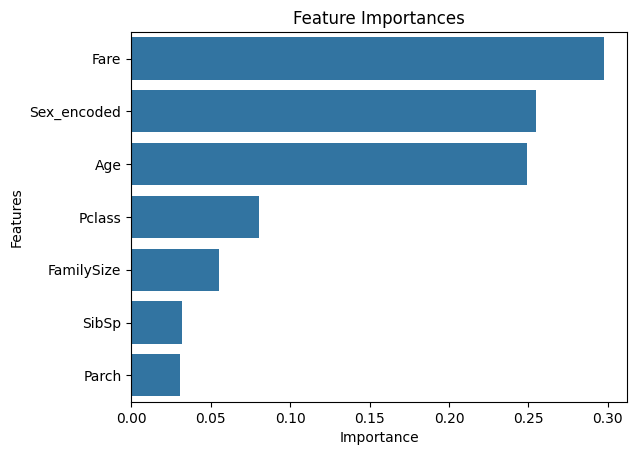

In [32]:
importances = pd.Series(
    model.feature_importances_,
    index=features
).sort_values(ascending=False)

sns.barplot(x=importances.values, y=importances.index)
plt.title("Feature Importances")
plt.ylabel("Features")  # add this line
plt.xlabel("Importance")  # add this line
plt.show()

Run the confusion matrix to see exactly where the model is making mistakes:

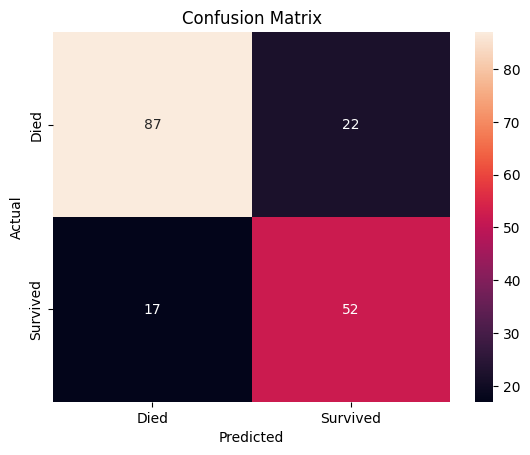

In [33]:
cm = confusion_matrix(y_test, predictions)
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Died', 'Survived'],
            yticklabels=['Died', 'Survived'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

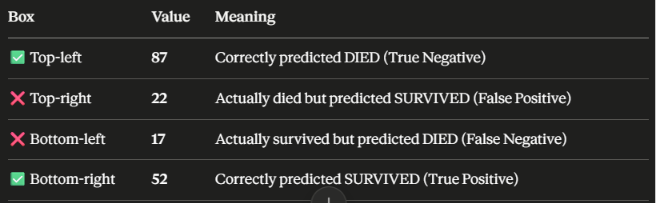